In [4]:
# ==========================================================
#            DIABETES PREDICTION - FINAL PROJECT
# ==========================================================

# -------------------- 1. Import Libraries --------------------

import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (8,6)



In [2]:


# -------------------- 2. Load Dataset --------------------

df = pd.read_csv("diabetes_prediction_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())


NameError: name 'pd' is not defined

In [4]:

# -------------------- 3. Basic Data Visualization --------------------

# 🔵 Pie Chart - Class Distribution
plt.figure()
df['diabetes'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#4CAF50','#F44336'],
    startangle=90,
    shadow=True
)
plt.title("Diabetes Distribution")
plt.ylabel("")
plt.show()


# 🔵 Histogram - Age
plt.figure()
sns.histplot(df['age'], kde=True, color="#2196F3")
plt.title("Age Distribution")
plt.show()


# 🔵 Histogram - BMI
plt.figure()
sns.histplot(df['bmi'], kde=True, color="#9C27B0")
plt.title("BMI Distribution")
plt.show()


# 🔵 Boxplot - Glucose vs Diabetes
plt.figure()
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df, palette="coolwarm")
plt.title("Blood Glucose Level vs Diabetes")
plt.show()



NameError: name 'plt' is not defined

In [7]:


# -------------------- 4. Encoding Categorical Variables --------------------

df = pd.get_dummies(df, drop_first=True)


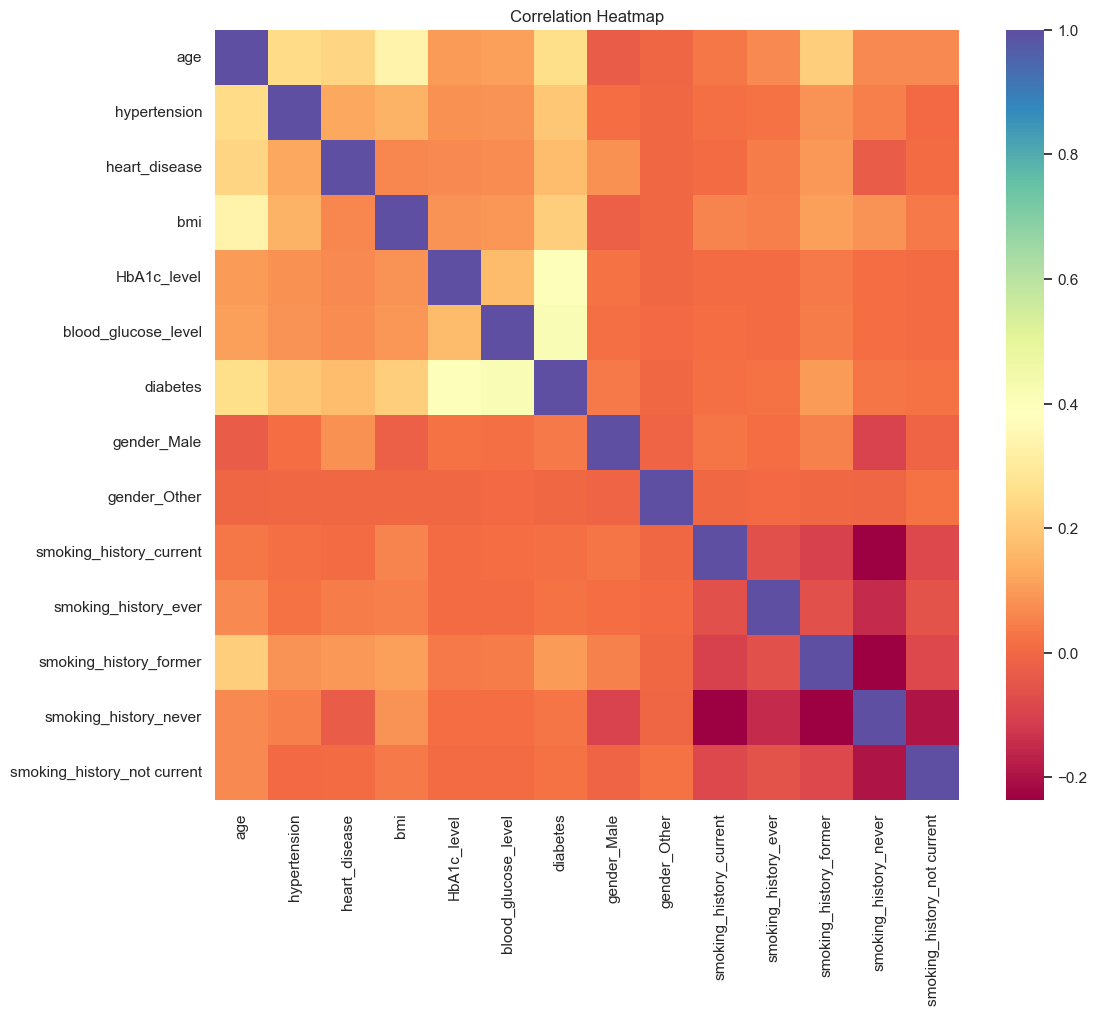

In [8]:
# -------------------- 5. Correlation Heatmap --------------------

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="Spectral", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [9]:

# -------------------- 6. Feature and Target Split --------------------

X = df.drop("diabetes", axis=1)
y = df["diabetes"]





In [10]:

# -------------------- 7. Train-Test Split --------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# -------------------- 8. Feature Scaling --------------------

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [12]:
# -------------------- 9. Model Training --------------------

models = {
    "SVM": svm.SVC(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results[name] = accuracy_score(y_test, pred)

    print(f"\n{name} Performance")
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))



SVM Performance
Accuracy : 0.96135
Precision: 0.9736575481256332
Recall   : 0.5626463700234192
F1 Score : 0.7131725417439703

Random Forest Performance
Accuracy : 0.97
Precision: 0.9453376205787781
Recall   : 0.6885245901639344
F1 Score : 0.7967479674796748

Gradient Boosting Performance
Accuracy : 0.9726
Precision: 0.9898648648648649
Recall   : 0.6861826697892272
F1 Score : 0.8105117565698479

Decision Tree Performance
Accuracy : 0.95265
Precision: 0.7143661971830986
Recall   : 0.7423887587822015
F1 Score : 0.7281079529141544


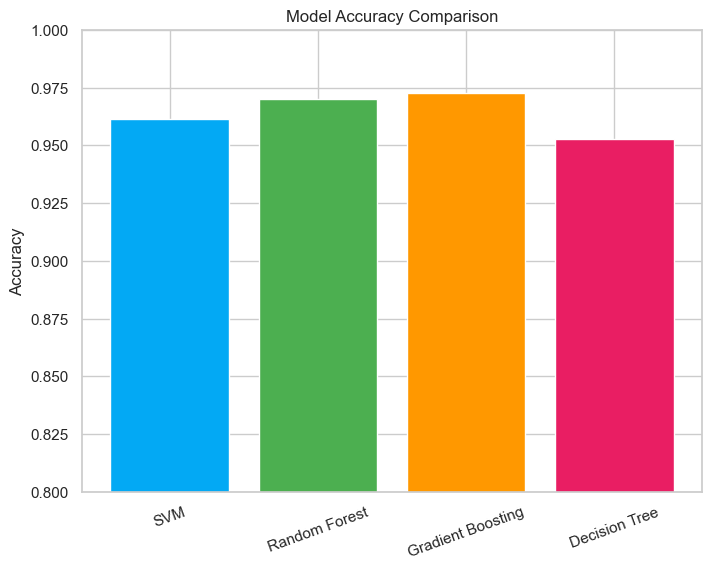

In [13]:

# -------------------- 10. Accuracy Comparison Chart --------------------

plt.figure()
plt.bar(results.keys(), results.values(),
        color=['#03A9F4','#4CAF50','#FF9800','#E91E63'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8,1.0)
plt.xticks(rotation=20)
plt.show()




In [14]:
# -------------------- 11. Hyperparameter Tuning --------------------

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [None,10,20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

print("\nBest Parameters:", grid.best_params_)



Best Parameters: {'max_depth': 10, 'n_estimators': 100}


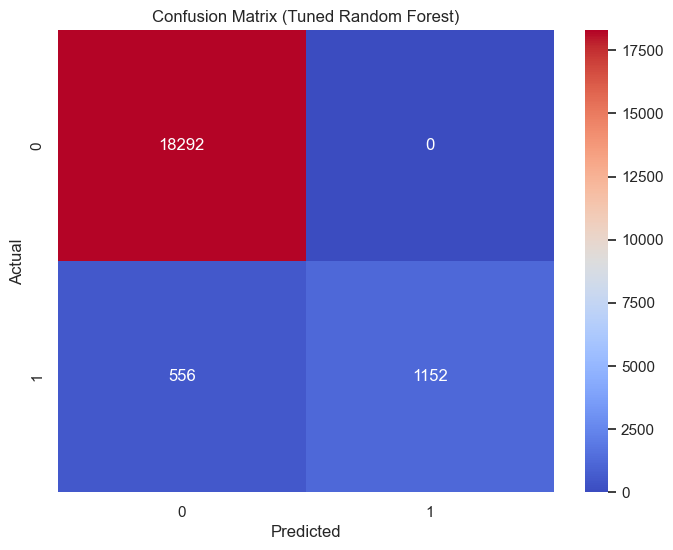

In [15]:
# -------------------- 12. Confusion Matrix --------------------

cm = confusion_matrix(y_test, best_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

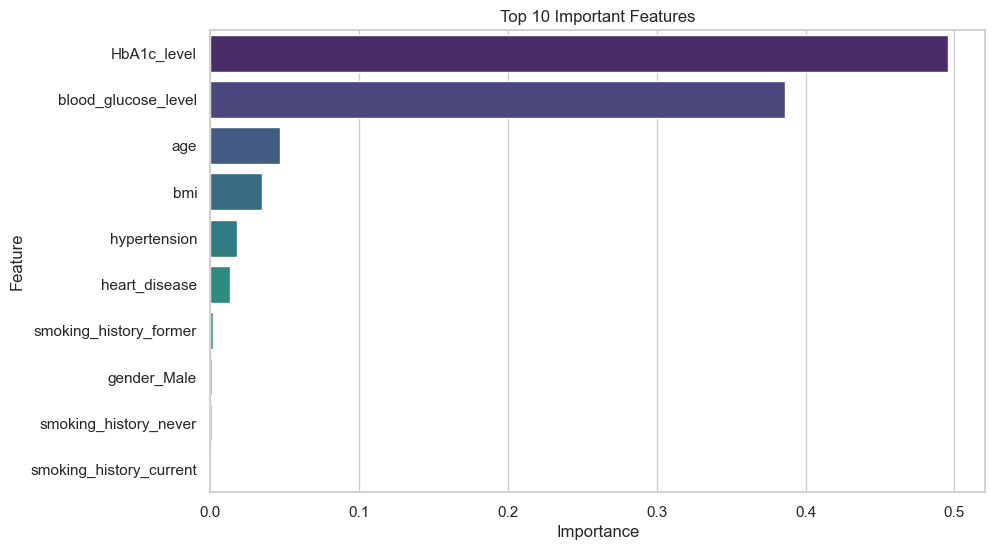


Model Saved Successfully!


In [16]:

# -------------------- 13. Feature Importance --------------------

importances = best_model.feature_importances_
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature',
            data=feature_df.head(10),
            palette="viridis")
plt.title("Top 10 Important Features")
plt.show()

# -------------------- 14. Save Model --------------------

joblib.dump(best_model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel Saved Successfully!")